# 1. 데이터 전처리
The current data is a file with more than 100 attributes reduced to 23.
year=year
nkilled=number of victims
nkilledter=number of died terrorists
nwounded=number of wounded people
nwoundedter= number of wounded terrorist 
lat=latitude 
lon=longitude 
region=region
country=country
weapontype=weapon type
attacktype=attack type 
targettype=victim type
gname=terrorist group name 
state=state 
city=city 
extended=extended case
multiple=part of another case 
success=terror success 
suicide=suicide terror 
nter=number of terrorists
claimed=responsibility
property=property loss 
propertyextend=extent of damage to property 
countrycode=country code

What you need from these are 'year, county, region, state, city, lat, lon, attaktype, nter, weapontype, nkilled, countycode'

1, 3, 4, 5, 6, 7, 8, 12, 15, 17, 18, 24

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
usecols = ['year', 'country', 'region', 'state', 'lat', 'lon', 'attacktype', 'nter', 'weapontype', 'nkilled', 'countrycode']


In [39]:
import pandas as pd
import numpy as np

df = pd.read_csv('terror/globalterrorism.csv', encoding='ISO-8859-1', usecols=usecols)

In [40]:
df.describe()
#There are 5 attributes(usually numbers)
#describe function -> mean, standard deviation, minimum value, percentage, maximum value

,year,lat,lon,nter,nkilled
count,152252.000000,152252.000000,152252.000000,152252.000000,152252.000000
mean,2000.749567,23.191058,24.210311,5.483297,2.175919
std,12.967771,19.220766,59.900997,177.330551,11.031467
min,1970.000000,-53.154613,-176.176447,0.000000,0.000000
25%,1989.000000,10.756834,-1.929857,0.000000,0.000000
50%,2006.000000,31.285506,41.919646,0.000000,0.000000
75%,2013.000000,34.842233,68.416974,0.000000,1.000000
max,2015.000000,74.633553,179.366667,25000.000000,1500.000000


In [41]:
df

,year,country,region,state,lat,lon,attacktype,nter,weapontype,nkilled,countrycode
0,1970,Dominican Republic,Central America & Caribbean,Unknown,18.456792,-69.951164,Assassination,0,Unknown,1,DOM
1,1970,Mexico,North America,Unknown,19.432608,-99.133207,Hostage Taking (Kidnapping),7,Unknown,0,MEX
2,1970,Philippines,Southeast Asia,Tarlac,15.478598,120.599741,Assassination,0,Unknown,1,PHL
3,1970,Greece,Western Europe,Attica,37.983773,23.728157,Bombing/Explosion,0,Explosives/Bombs/Dynamite,0,GRC
4,1970,Japan,East Asia,Unknown,33.580412,130.396361,Facility/Infrastructure Attack,0,Incendiary,0,JPN
...,...,...,...,...,...,...,...,...,...,...,...
152247,2015,Burundi,Sub-Saharan Africa,Bujumbura Mairie,-3.382229,29.366784,Bombing/Explosion,0,Explosives/Bombs/Dynamite,1,BDI
152248,2015,Ireland,Western Europe,Cork,51.906466,-8.505583,Bombing/Explosion,0,Explosives/Bombs/Dynamite,0,IRL
152249,2015,Philippines,Southeast Asia,Lanao del Sur,7.999676,124.299806,Armed Assault,0,Firearms,1,PHL
152250,2015,Somalia,Sub-Saharan Africa,Middle Juba,1.642952,42.450358,Hostage Taking (Kidnapping),0,Unknown,5,SOM


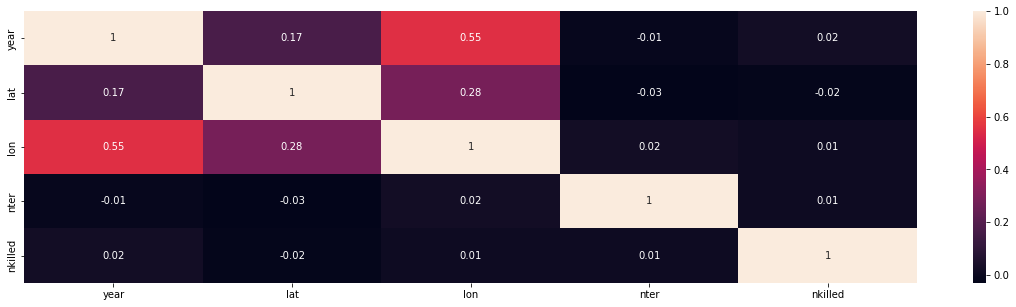

In [42]:
plt.figure(figsize=(20, 5))
correlation_matrix = df.corr().round(2)
sns.heatmap(data=correlation_matrix, annot=True)
plt.show()

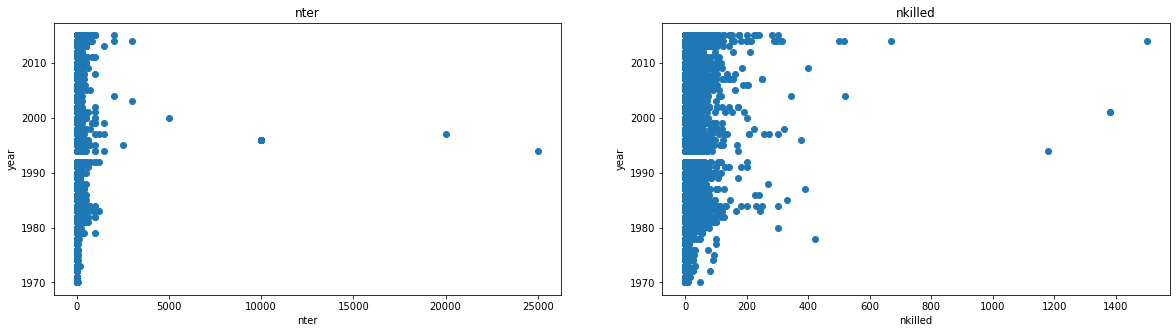

In [43]:
plt.figure(figsize=(20, 5))
features = ['nter', 'nkilled'] 
target = df['year']
for i, col in enumerate(features):
    plt.subplot(1, len(features) , 1+i) 
    x = df[col]
    y = target 
    plt.scatter(x, y, marker='o') 
    plt.title(col) #title.
    plt.xlabel(col)
    plt.ylabel('year')

## Step1
Extract only relevant data from attacktype

In [44]:
arms = (df.weapontype =='Explosives/Bombs/Dynamite') |  (df.weapontype =='Firearms') \
| (df.weapontype =='Melee') | (df.weapontype =='Chemical')
arms_df = pd.DataFrame(arms)
arms_df = df[arms]

 ### When you sort the column, you can see that there were 130628 terrors using weapons.

In [45]:
year = arms_df.groupby('year')
attacktype = arms_df.groupby('attacktype')
weapontype = arms_df.groupby('weapontype')
country = arms_df.groupby('country')
region = arms_df.groupby('region')
state = arms_df.groupby('state')
lat = arms_df.groupby('lat')
lon = arms_df.groupby('lon')
countrycode = arms_df.groupby('countrycode')
nter = arms_df.groupby('nter')
nkilled = arms_df.groupby('nkilled')

In [46]:
year.size()

year
1970      420
1971      341
1972      447
1973      373
1974      490
1975      625
1976      697
1977      947
1978     1094
1979     1901
1980     2047
1981     2040
1982     1969
1983     2252
1984     2665
1985     2229
1986     2148
1987     2498
1988     3148
1989     3740
1990     3316
1991     3883
1992     3949
1994     2507
1995     2008
1996     2138
1997     2214
1998      795
1999     1098
2000     1521
2001     1609
2002     1169
2003     1107
2004     1055
2005     1819
2006     2508
2007     3003
2008     4119
2009     4008
2010     4182
2011     4477
2012     7924
2013    10935
2014    14683
2015    12583
dtype: int64

In [47]:
attacktype.size()

attacktype
Armed Assault                          33732
Assassination                          15611
Bombing/Explosion                      73965
Facility/Infrastructure Attack          1028
Hijacking                                353
Hostage Taking (Barricade Incident)      639
Hostage Taking (Kidnapping)             4697
Unarmed Assault                          647
Unknown                                    9
dtype: int64

In [48]:
weapontype.size()

weapontype
Chemical                       203
Explosives/Bombs/Dynamite    77755
Firearms                     49801
Melee                         2922
dtype: int64

In [49]:
nkilled.size()

nkilled
0       68095
1       28054
2       10628
3        5798
4        3704
        ...  
517         1
518         1
670         1
1180        1
1500        1
Length: 176, dtype: int64

In [50]:
arms_df.to_csv('terror/arms_DF_ver2.csv', encoding = 'ISO-8859-1', index=False)